In [1]:
import pandas as pd

df = pd.read_csv("../data/processed/telco_segmented.csv")
df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,TotalServices,AvgMonthlyValue,ContractRisk,AutoPay,EngagementScore,...,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,TenureGroup_Mid,TenureGroup_New,Segment
0,0,1,29.85,29.85,0,1,14.925000,2,1,0.083333,...,False,False,False,True,False,True,False,False,True,1
1,0,34,56.95,1889.50,0,3,53.985714,1,1,8.833333,...,False,True,False,False,False,False,True,True,False,0
2,0,2,53.85,108.15,1,3,36.050000,2,1,4.166667,...,False,False,False,True,False,False,True,False,True,1
3,0,45,42.30,1840.75,0,3,40.016304,1,0,9.750000,...,False,True,False,False,False,False,False,False,False,0
4,0,2,70.70,151.65,1,1,50.550000,2,1,0.166667,...,False,False,False,True,False,True,False,False,True,2


In [3]:
cols_to_drop = ["Churn", "customerID", "Segment", "TenureGroup"]

existing_cols = [c for c in cols_to_drop if c in df.columns]

X = df.drop(columns=existing_cols)
y = df["Churn"]

In [4]:
X = pd.get_dummies(X, drop_first=True)

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [6]:
X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_train.median())

In [7]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

/Users/gauravverma/customer-intelligence/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [8]:
from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, lr_pred))
print("ROC-AUC:", roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]))

              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1035
           1       0.65      0.50      0.57       374

    accuracy                           0.80      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.79      0.80      0.79      1409

ROC-AUC: 0.8409853005760934


In [9]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [10]:
print(classification_report(y_test, rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]))

              precision    recall  f1-score   support

           0       0.73      1.00      0.85      1035
           1       0.00      0.00      0.00       374

    accuracy                           0.73      1409
   macro avg       0.37      0.50      0.42      1409
weighted avg       0.54      0.73      0.62      1409

ROC-AUC: 0.8303056136815727


/Users/gauravverma/customer-intelligence/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/gauravverma/customer-intelligence/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/gauravverma/customer-intelligence/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

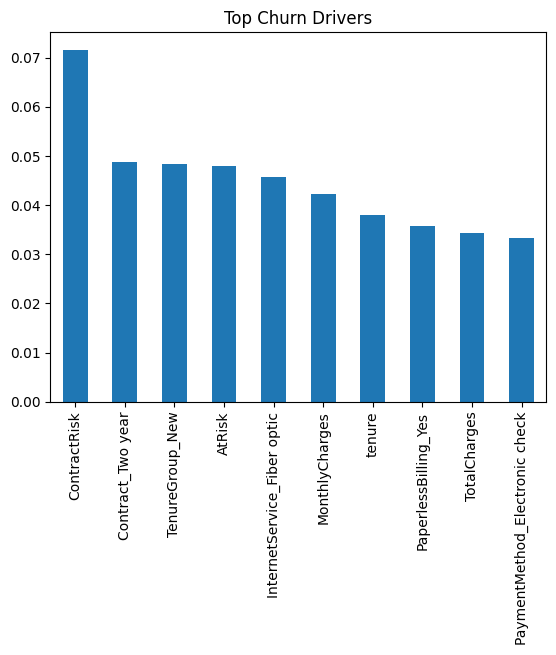

In [11]:
import matplotlib.pyplot as plt
import pandas as pd

importances = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importances.head(10).plot(kind="bar")
plt.title("Top Churn Drivers")
plt.show()

In [12]:
import joblib

joblib.dump(rf, "../models/churn_model.pkl")

['../models/churn_model.pkl']

In [13]:
df.to_csv("../data/processed/telco_ml_ready.csv", index=False)